<a href="https://colab.research.google.com/github/MantaHonk/EOS_Weather_Data_Analysis/blob/main/Tutorial_4_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tutorial 4: Inference and Time Series Data

In this tutorial we have the following objectives:

* Learn how to make and apply statistical inference

* Work with time series data, including concepts of: filters, anomalies, and standardization


In [ ]:
# connect to the git hub repository
!git clone https://github.com/wicks-uvic/data_230_202601

fatal: destination path 'data_230_202601' already exists and is not an empty directory.


In [ ]:
# add file path(s) and file name(s) as variables

In [ ]:
# import libaries
import pandas as pd
import glob
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro,kstest,norm
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller



---

**Only run these code on final run before pdf export**

In [ ]:
# install additional required libraries
# only run on fianl run before pdf export
!pip -q install kaleido==0.2.1

In [ ]:
# import library to convert plotly html plots to png for pdf export
# only run on fianl run before pdf export
import plotly.io as pio
pio.renderers.default = "png"

---

## Part A - Determine the probability for a given value

###1. Make a bar plot showing annual sums for “Total Precip (mm)”. Use appropriate axis labels. (2 marks).

###The 2008 values are quite low - why? what might we suspect is happening in this case? (3 marks)

> For the rest of exercise, we will assume the value is good and that it is just an unusual year. Our objective is to determine how unusual it was. To do this we will fit a distribution (a statistical model) to make inferences.

In [ ]:
# add your code to read in the data here
# Use glob to find all CSV files in the specified directory
file_paths = glob.glob('data_230_202601/tutorial_4/*.csv')

# Initialize an empty list to store individual DataFrames
dfs = []
# add your code to read in the data here
# Loop through each file path, read the CSV, parse dates, set index, and append to the list
for file_path in file_paths:
    df = pd.read_csv(file_path, parse_dates=['Date/Time'], index_col='Date/Time')
    dfs.append(df)

# Concatenate all DataFrames into a single DataFrame, preserving original indices
df = pd.concat(dfs, ignore_index=False)
if 'Date/Time' in df.columns:
  df['Date'] = pd.to_datetime(df['Date/Time'])

  df = df.set_index('Date')
  df = df.sort_index() # Ensure chronological order


> write your answer here

---
There are a few things we can consider happening in 2008. The first being the year was particularily dry, a natural climate occurance. Secondly, we could have it that there is some missing data for the year. It is possible that we are missing a period of time and it is affecting the total precip in 2008. There could also be an alternative issue with the data collection where possibly the sensors malfunctioned.


###2. Create a histogram. Create a title for the plot where the "mu" (μ) and "sigma" (σ) are assigned by variables in an f-string (3 marks) and describe the distribution of the graph (2 marks).

- This introduces the concept of automating output and building tailored analysis packages, where you can input a dataset and have it plotted with all relevant information included.


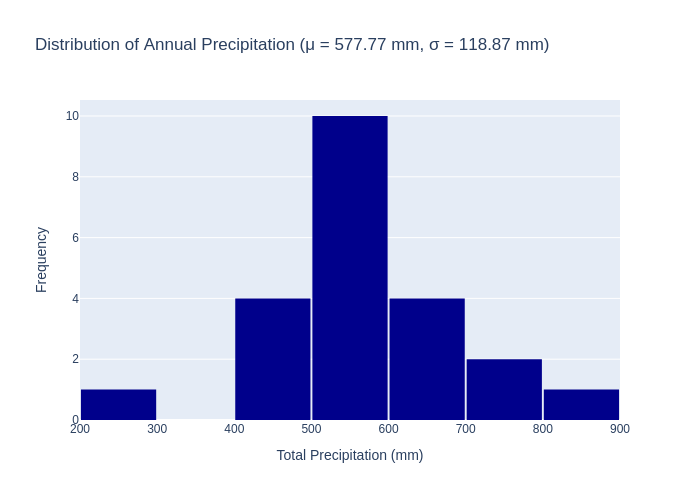

In [ ]:
# Calculate mean (mu) and standard deviation (sigma)
annual_precip = df['Total Precip (mm)'].resample('YE').sum()
mu = annual_precip.mean()
sigma = annual_precip.std()

# Create the dynamic title using an f-string
plot_title = f"Distribution of Annual Precipitation (μ = {mu:.2f} mm, σ = {sigma:.2f} mm)"

# Create the histogram using Plotly
fig = go.Figure(
    data=[
        go.Histogram(
            x=annual_precip.values,
            marker_color='darkblue',
            name='Annual Precipitation'
        )
    ]
)

fig.update_layout(
    title=plot_title,
    xaxis_title='Total Precipitation (mm)',
    yaxis_title='Frequency',
    bargap=0.025,
    hovermode='x unified'
)

fig.show()

> write your answer here

---
The above graph is normally distributed and centered on mu = 577.77 mm of precipitation. It is left skewed with the majority of elements being on the greater-end of the histogram while still being central. The single observation in the 200-300 mm bin could potentially be an outlier, and referencing the previous bar plot we observe that it is the 2008 year again.


###3. Create a Gaussian probability density function (a PDF) plot from the data. Explain how it works (3 marks). Why do you need `np.linspace()`? (2 marks)

- Use `from scipy.stats import norm` see geeks for geeks documentation [here](https://www.geeksforgeeks.org/python/scipy-stats/)

- You can also read over Scipy documents [here](https://docs.scipy.org/doc/scipy/tutorial/stats.html), but these are very stats heavy


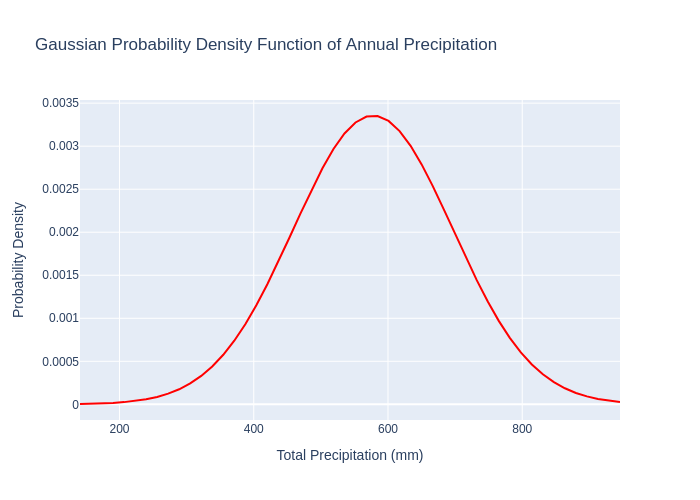

In [ ]:
import numpy as np
from scipy.stats import norm

# Calculate the Probability Density Function (PDF) for these x-values
x = np.linspace(annual_precip.min() - sigma, annual_precip.max() + sigma, 50)
y = norm.pdf(x,loc=mu,scale=sigma)
# Create the PDF plot using Plotly
fig = go.Figure(
    data=[
        go.Scatter(
            x=x,
            y=y,
            mode='lines',
            line=dict(color='red', width=2)
        )
    ]
)

fig.update_layout(
    title='Gaussian Probability Density Function of Annual Precipitation',
    xaxis_title='Total Precipitation (mm)',
    yaxis_title='Probability Density',
    hovermode='x unified'
)

fig.show()

> write your answer here

---
The np.linspace() function is an abbreviation for linear space. It is like a vector of numbers of even proportions, or a sequence of evenly spaced numvers over a defined interval. For our case, we go from the minimum of the df to the maximum with 50 datapoints.

###4. Combine the Gaussian probability density function and the histogram (3 marks). The histogram must be generated in terms of the Gaussian y-values, which are individual probabilities. Use the title you created in question 2 above. Describe how well they fit together (2 marks).

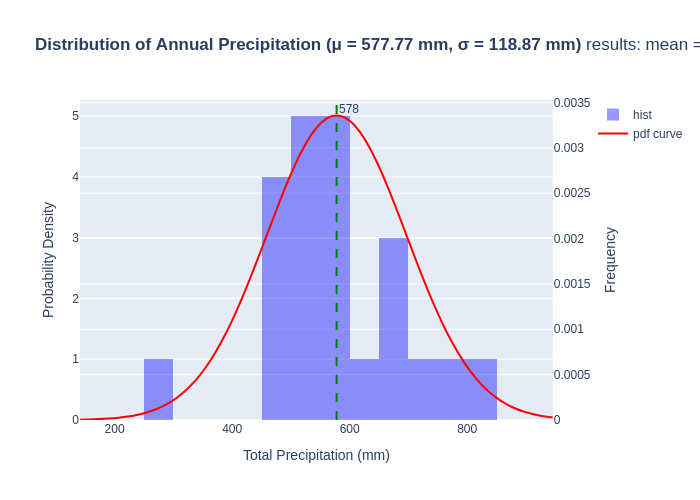

In [ ]:
def histogram_scatter_plot(x_hist,x,y,linecolour,histcolour,mu,std,vline,title_label='title missing',x_label='x-axis name',y_label_p='y-axis 1 name',y_label_s='y-axis 2 name'):
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    # Add traces
    fig.add_trace(go.Histogram(
            x=x_hist,
            nbinsx=20,
            name = 'hist',
            marker_color = histcolour,
            opacity=0.4
        ),secondary_y=False,)
    fig.add_trace(go.Scatter(
            x=x, y=y,
            mode="lines",
            line=dict(color=linecolour, width=2), #, dash='dot'),
            name='pdf curve',
            line_shape='spline'
            ),secondary_y=True,)

    # Add figure title
    fig.update_layout(
        title_text =f'<b>{title_label}</b> results: mean = {mu:.0f}, std = {std:.0f}'
        )

    # Set x-axis title
    fig.update_xaxes(title_text=f"{x_label}") # change xaxis title

    # Set y-axes titles
    fig.update_yaxes(title_text=f"{y_label_p}", secondary_y=False) # change yaxis title
    fig.update_yaxes(title_text=f"{y_label_s}", secondary_y=True,rangemode='tozero') # change second yaxis title

    fig.add_vline(x=vline, line_width=2, line_dash="dash", line_color="green",annotation_text=f'{vline:.0f}')

    return fig
# Corrected function call: removed extra comma and passed 'vline' as a keyword argument
fig = histogram_scatter_plot(x_hist=annual_precip, x=x, y=y, linecolour='red', histcolour='blue', mu=mu, std=sigma, vline=mu, title_label=plot_title, x_label='Total Precipitation (mm)', y_label_p='Probability Density', y_label_s='Frequency')
fig.show()

> write your answer here

---
It appears that the gaussian curve approximately follows the normality of our histogram. The majority of the data is underneath the curve, and the other points are not far from the line.


###5. Determine whether the distribution is reasonably Gaussian by using the Shapiro-Wilk test. Print and interpret your results (10 marks).

- `stats.shapiro()` documentation [here](https://docs.scipy.org/doc/scipy/tutorial/stats/hypothesis_shapiro.html)

- additional resource for reading the results [here](https://www.statology.org/normality-test-python/)

In [ ]:
from scipy.stats import shapiro

statistic, p_value = shapiro(annual_precip)

print(f"Shapiro-Wilk Test Statistic (W): {statistic:.3f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05 #The boundary point for the conclusion of our p-val test
print(f"\nInterpretation (alpha = {alpha}):")
if p_value > alpha:
    print("P-value > alpha: Fail to reject H0. The data appears to be normally distributed.")
else:
    print("P-value <= alpha: Reject H0. The data does not appear to be normally distributed.")

Shapiro-Wilk Test Statistic (W): 0.943
P-value: 0.230

Interpretation (alpha = 0.05):
P-value > alpha: Fail to reject H0. The data appears to be normally distributed.


> write your answer here

---
Since our p-value, 0.23 from the shapiro test is less than the threshold for rejection alpha= 0.05, we fail to reject the hypothesis that our gaussian is normally distributed by lack of evidence.


###6. (a) Determine the probability of a year with precipitation less than the 2008 value (5 marks).

- Check out [this](https://stackoverflow.com/questions/12412895/how-to-calculate-probability-in-a-%20normal-distribution-given-mean-standard-devi) stack question which is useful

- Scroll down to the response that has "frozen distribution" in its first sentence, about 1/3 the way down.


In [ ]:
from scipy.stats import norm

precip_2008 = annual_precip[annual_precip.index.year == 2008].iloc[0]

probability = norm.cdf(precip_2008, loc=mu, scale=sigma)

print(f"2008 Annual Precipitation: {precip_2008:.2f} mm")
print(f"Mean annual precipitation (μ): {mu:.2f} mm")
print(f"Standard deviation of annual precipitation (σ): {sigma:.2f} mm")
print(f"\nThe probability of a year having precipitation less than {precip_2008:.2f} mm (the 2008 value) is: {probability:.4f}")

2008 Annual Precipitation: 260.00 mm
Mean annual precipitation (μ): 577.77 mm
Standard deviation of annual precipitation (σ): 118.87 mm

The probability of a year having precipitation less than 260.00 mm (the 2008 value) is: 0.0038


> write your answer here

---
As noted in the print statements above, we find that the probability of a year with less precipitation than in 2008, 260.00 mm, is 0.0038 by the normal distribution.


###6. (b)	You are working with a client who is worried about another low precip year - it will damage their crop. If it is likely we will have another year similar to 2008, they will plant another type of crop that is more tolerant of low precip. What do you advise them based on the data you have and the results you have generated? (5 marks)

In [ ]:
# add your code here


> write your answer here

---
Although our data is found to be not normally distributed because we failed to reject Ho, we still determined the probability of a year having less rain than in 2008 to be extremely unlikely, with a probability of 0.038, which is approximately once every 250 years. Because it is normally distributed, we have a higher confidence that our data and findings are expected and predictable.
As for the advisory, I would strongly suggest to the client that it is not necessary to switch crops for the reason of low precipitation given the statistical evidence.


##Part B: Filters and Pattern Removal

###7. Extract mean temperature from the Gonzales dataset and plot the first two years; include axis labels (2 marks). What patterns do you observe? Explain (3 marks).

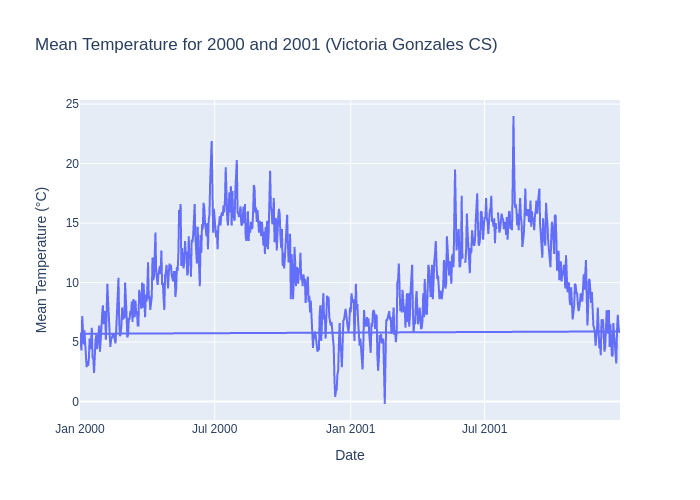

In [ ]:
# add your code here

# Extract mean temperature
mean_temp = df['Mean Temp (°C)']

# Get the start year of the dataset
start_year = mean_temp.index.year.min()

# Filter for the first two years and rename the variable to df2
mean_df = mean_temp[mean_temp.index.year.isin([start_year, start_year + 1])]

# Create a line plot using Plotly
fig = go.Figure(
    data=[
        go.Scatter(
            x=mean_df.index,
            y=mean_df.values,
            mode='lines',
            name='Mean Temperature'
        )
    ]
)

# Update layout for appropriate labels and title
fig.update_layout(
    title=f'Mean Temperature for {start_year} and {start_year + 1} (Victoria Gonzales CS)',
    xaxis_title='Date',
    yaxis_title='Mean Temperature (°C)',
    hovermode='x unified'
)

fig.show()

> write your answer here

---

We observe the seasonal changes found in the victoria gonzales weather station. As its location is in the mid-latitude shielded by the olympics, we notice a generally moderate climate without long stretches of extreme temperatures. We notice that the oscillating weather pattern is consistent for the two years and there are no abrupt changes. By only observing these two years, we do not notice any immediate changes between the two years, likely due to the fact that the scope is not large enough.

###8. Calculate the mean for each day across all years `.groupby([month,day])` and create a quick plot. This graph should start on Jan 1st and end on Dec 31st. You might encounter a problem - explain it if you do (10 marks)

- Hint: Feb

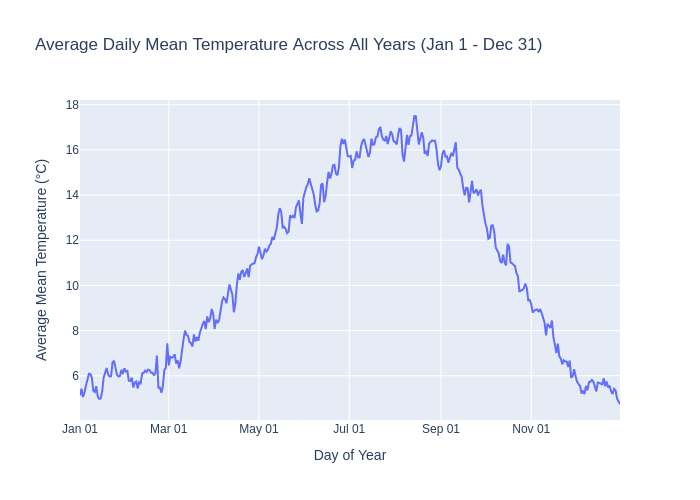

In [ ]:
# add your code here



daily_mean_temp = df.groupby([df.index.month, df.index.day])['Mean Temp (°C)'].mean()
daily_mean_temp = daily_mean_temp.rename_axis(index=['Month', 'Day']).reset_index()


daily_mean_temp['Date_for_plot'] = pd.to_datetime('2000-' + daily_mean_temp['Month'].astype(str) + '-' + daily_mean_temp['Day'].astype(str), errors='coerce')

# Handle the problem: February 29th will become NaT (Not a Time) in non-leap years
# We will drop these NaT values for plotting a continuous series for a standard year
daily_mean_temp = daily_mean_temp.dropna(subset=['Date_for_plot'])

daily_mean_temp = daily_mean_temp.sort_values('Date_for_plot')

fig = go.Figure(
    data=[
        go.Scatter(
            x=daily_mean_temp['Date_for_plot'],
            y=daily_mean_temp['Mean Temp (°C)'],
            mode='lines',
            name='Average Daily Mean Temperature'
        )
    ]
)


fig.update_layout(
    title='Average Daily Mean Temperature Across All Years (Jan 1 - Dec 31)',
    xaxis_title='Day of Year',
    yaxis_title='Average Mean Temperature (°C)',
    hovermode='x unified',
    xaxis=dict(tickformat='%b %d')
)

fig.show()

> write your answer here

---

The problem we observed was caused by the variation in the amount of days in a year. On leap years, February has an extra day. However, since we are plotting a time series, the NaaN value causes issues. We fixed this issue by removing data collected on any February 29th.

###9. Create a new dataset `.groupby(year.month)` and use an ADF test to check for stationarity of each month the over years of the dataset (10 marks).

- you will need to `.unstack()` your grouped dataset

- once your dataset is 'unstacked' you will need to test stationarity on each column (month)




In [ ]:
# add your code here


monthly_mean_temp_series = df.groupby([df.index.year, df.index.month])['Mean Temp (°C)'].mean()

monthly_mean_temp_df = monthly_mean_temp_series.unstack()

def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    return result[1]  # Return the p-value

was_stationary = []
was_not_stationary = []
for month in range(1,13,1):
    p_value = check_stationarity(monthly_mean_temp_df.unstack()[month].dropna())
    print(f"Month '{month}': p-value = {p_value}")

    if p_value <= 0.05:
        was_stationary.append(month)
        print(f"  --> The series is likely stationary")
    else:
        was_not_stationary.append(month)
        print(f"  --> The series is likely non-stationary")

    print()

Month '1': p-value = 0.7814230025218907
  --> The series is likely non-stationary

Month '2': p-value = 0.00014395205953439248
  --> The series is likely stationary

Month '3': p-value = 1.1928038227646817e-05
  --> The series is likely stationary

Month '4': p-value = 0.5752285370269838
  --> The series is likely non-stationary

Month '5': p-value = 0.1344217267492791
  --> The series is likely non-stationary

Month '6': p-value = 0.02797450195205199
  --> The series is likely stationary

Month '7': p-value = 0.05123718289742655
  --> The series is likely non-stationary

Month '8': p-value = 0.16513415651679325
  --> The series is likely non-stationary

Month '9': p-value = 1.0664081480738237e-10
  --> The series is likely stationary

Month '10': p-value = 0.08506654614498715
  --> The series is likely non-stationary

Month '11': p-value = 0.8840037567235418
  --> The series is likely non-stationary

Month '12': p-value = 1.0
  --> The series is likely non-stationary



> write your answer here

---
By definition, a stationary time series is one that remains constant over time. In the context of climate, a stationary time series would be ideal, or possibly a non-stationary climate in terms of temperature decreasing. By the ADF test, the following months are likely to be stationary, or constant: February, March, June, and September. These were found by a p-value and were rejected by the null hypothesis being under alpha = 0.05. The remaining 8 months were all found to likely be non-stationary, suggesting a trend in temperature change.


###10. Identify seasonality in the mean temp dataset. Use the STL decomposition method from [`statsmodels.tsa.seasonal`](https://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.STL.html) and create a decomposition plot (10 marks).

- you will need to use `asfreq('D').interpolate('time')` to fill gaps in the data for the STL to work

- you may also need to set the index to the result series for the plots to display

- you can use Plotly or Matplotlib

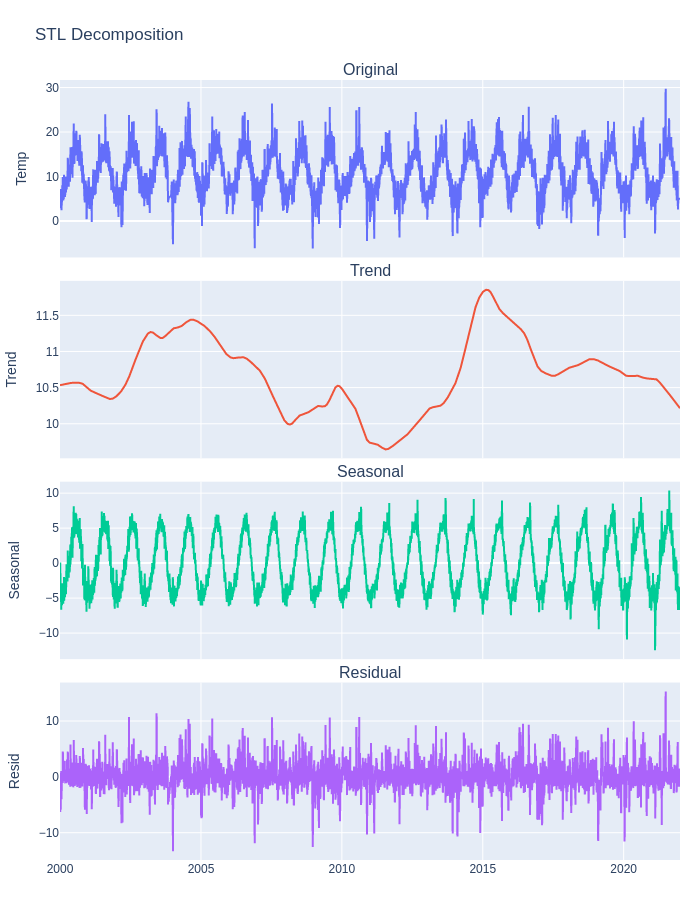

In [ ]:
# add your code here
temp_d = df['Mean Temp (°C)'].asfreq("D").interpolate("time")

stl = STL(temp_d, period=365, seasonal=13, robust=True)
res = stl.fit()

trend    = pd.Series(res.trend,    index=temp_d.index, name="trend")
seasonal = pd.Series(res.seasonal, index=temp_d.index, name="seasonal")
resid    = pd.Series(res.resid,    index=temp_d.index, name="resid")


fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    subplot_titles=("Original", "Trend", "Seasonal", "Residual")
)

fig.add_trace(go.Scatter(x=temp_d.index, y=temp_d.values, mode="lines", name="Original"), row=1, col=1)
fig.add_trace(go.Scatter(x=trend.index,  y=trend.values,  mode="lines", name="Trend"),    row=2, col=1)
fig.add_trace(go.Scatter(x=seasonal.index, y=seasonal.values, mode="lines", name="Seasonal"), row=3, col=1)
fig.add_trace(go.Scatter(x=resid.index,  y=resid.values,  mode="lines", name="Residual"), row=4, col=1)

fig.update_traces(showlegend=False)

fig.update_layout(
    height=900,
    title_text="STL Decomposition",
    margin=dict(l=60, r=20, t=80, b=40)
)

fig.update_yaxes(title_text="Temp", row=1, col=1)
fig.update_yaxes(title_text="Trend", row=2, col=1)
fig.update_yaxes(title_text="Seasonal", row=3, col=1)
fig.update_yaxes(title_text="Resid", row=4, col=1)

fig.show()


###11. For the months where the data are not stationary, transform the data and re-check for stationarity (10 marks).

###use the differenceing method from lecture `.diff()`


In [ ]:
# add your code here
# For the months where the data are not stationary, transform the data and re-check for stationarity
# use the differencing method from lecture `.diff()`

print("Re-checking stationarity after differencing for non-stationary months:")
for month in was_not_stationary:
    # Extract the monthly time series
    monthly_series = monthly_mean_temp_df.unstack()[month].dropna()

    # Apply differencing
    differenced_series = monthly_series.diff().dropna()

    if not differenced_series.empty:
        p_value_diff = check_stationarity(differenced_series)
        print(f"Month '{month}' (after differencing): p-value = {p_value_diff:.7f}")

        if p_value_diff <= 0.05:
            print(f"  --> The differenced series for Month '{month}' is likely stationary")
        else:
            print(f"  --> The differenced series for Month '{month}' is likely non-stationary")
    else:
        print(f"Month '{month}': Not enough data to perform differencing and stationarity test.")
    print()

Re-checking stationarity after differencing for non-stationary months:
Month '1' (after differencing): p-value = 0.1767386
  --> The differenced series for Month '1' is likely non-stationary

Month '4' (after differencing): p-value = 0.0000000
  --> The differenced series for Month '4' is likely stationary

Month '5' (after differencing): p-value = 0.0205493
  --> The differenced series for Month '5' is likely stationary

Month '7' (after differencing): p-value = 0.0000002
  --> The differenced series for Month '7' is likely stationary

Month '8' (after differencing): p-value = 0.0010383
  --> The differenced series for Month '8' is likely stationary

Month '10' (after differencing): p-value = 0.0000032
  --> The differenced series for Month '10' is likely stationary

Month '11' (after differencing): p-value = 0.2776390
  --> The differenced series for Month '11' is likely non-stationary

Month '12' (after differencing): p-value = 0.9037224
  --> The differenced series for Month '12' i

> write your answer here

---
After performing the differencing technique, we found the following months, May, July, Auhust, and October to now be rejected by the null hypothesis and can say that they are likely stationary. January, November, and December see no change, and are still classified as likely non-stationary.


###12. For the months where the data are not stationary, transform the data and re-check for stationarity (10 marks).

###use the rolling mean method from lecture `.rolling().mean`

- create 3 series from the first 100 observations in the dataset:
  - unaltered
  - centered rolling mean `center=True`
  - triang rolling mean `win_type='triang`

- combine all three series into one DataFrame and plot them.

- describe the differences between the three lines and explain why they occur.

###additional resources:
- [pydata](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)

- [scipy](https://docs.scipy.org/doc/scipy/reference/signal.windows.html#module-)


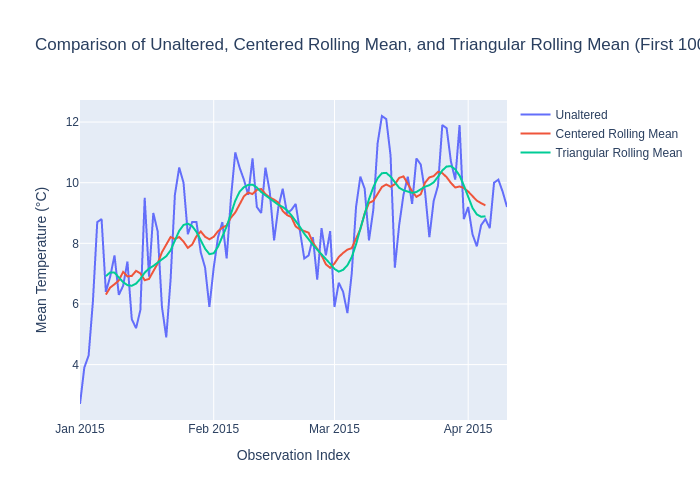

In [ ]:
first_100_obs = df['Mean Temp (°C)'].head(100)

unaltered_series = first_100_obs.copy()

centered_rolling_mean = first_100_obs.rolling(window=12, center=True).mean()

triang_rolling_mean = first_100_obs.rolling(window=12, win_type='triang', center=True).mean()

comparison_df = pd.DataFrame({
    'Unaltered': unaltered_series,
    'Centered Rolling Mean': centered_rolling_mean,
    'Triangular Rolling Mean': triang_rolling_mean
})

fig = go.Figure()

fig.add_trace(go.Scatter(x=comparison_df.index, y=comparison_df['Unaltered'], mode='lines', name='Unaltered'))
fig.add_trace(go.Scatter(x=comparison_df.index, y=comparison_df['Centered Rolling Mean'], mode='lines', name='Centered Rolling Mean'))
fig.add_trace(go.Scatter(x=comparison_df.index, y=comparison_df['Triangular Rolling Mean'], mode='lines', name='Triangular Rolling Mean'))

fig.update_layout(
    title='Comparison of Unaltered, Centered Rolling Mean, and Triangular Rolling Mean (First 100 Observations)',
    xaxis_title='Observation Index',
    yaxis_title='Mean Temperature (°C)',
    hovermode='x unified'
)

fig.show()


> write your answer here

---
The plot shows the differences between raw unaltered data and different averaging techniques for time series. We notive that hte centered rolling mean smoothes the data by creating partitions of the data and taking the average, reducing the strength of outliers or extreme values. The triangular rolling mean works similarily, but gives the center of the rolling window more weight. These trends can be seen by observing the plot, where the unaltered time series has much more variance, and the triangular rolling mean seems to be more centered around the unaltered time series than the centered rolling mean because of the weighting.